In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Customer_Revenue_Intelligence\data\processed\online_retail_clean.csv",
                 parse_dates=['InvoiceDate'])

rfm = pd.read_csv(r"C:\Customer_Revenue_Intelligence\data\processed\rfm_segments.csv")

print(f"Clean dataset loaded: {len(df):,} rows")
print(f"RFM dataset loaded: {len(rfm):,} customers")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Dataset span: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

Clean dataset loaded: 779,407 rows
RFM dataset loaded: 5,878 customers
Date range: 2009-12-01 to 2011-12-09
Dataset span: 738 days


In [2]:
dataset_years = 738 / 365

customer_clv = df.groupby('Customer ID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

customer_clv['AOV'] = (customer_clv['Total_Revenue'] / customer_clv['Total_Orders']).round(2)
customer_clv['Lifespan_Days'] = (customer_clv['Last_Purchase'] - customer_clv['First_Purchase']).dt.days
customer_clv['Lifespan_Years'] = (customer_clv['Lifespan_Days'] / 365).round(4)
customer_clv['Purchase_Frequency'] = customer_clv['Total_Orders']

avg_aov = customer_clv['AOV'].mean()
avg_frequency = customer_clv['Total_Orders'].mean()
avg_lifespan = customer_clv['Lifespan_Years'].mean()

customer_clv['CLV'] = (customer_clv['AOV'] * customer_clv['Total_Orders'] * 
                        (customer_clv['Lifespan_Years'] + 1)).round(2)

print("=== CLV COMPONENTS ===")
print(f"Dataset span: {dataset_years:.2f} years")
print(f"Average Order Value: £{avg_aov:,.2f}")
print(f"Average Purchase Frequency: {avg_frequency:.2f} orders per customer")
print(f"Average Customer Lifespan: {avg_lifespan:.4f} years ({avg_lifespan*365:.1f} days)")
print(f"\nCLV Statistics:")
print(f"Min CLV:    £{customer_clv['CLV'].min():,.2f}")
print(f"Max CLV:    £{customer_clv['CLV'].max():,.2f}")
print(f"Mean CLV:   £{customer_clv['CLV'].mean():,.2f}")
print(f"Median CLV: £{customer_clv['CLV'].median():,.2f}")
print(f"\nSample customer CLV values:")
print(customer_clv[['Customer ID','Total_Revenue','Total_Orders','AOV','Lifespan_Days','CLV']].head(10).to_string())

=== CLV COMPONENTS ===
Dataset span: 2.02 years
Average Order Value: £385.18
Average Purchase Frequency: 6.29 orders per customer
Average Customer Lifespan: 0.7480 years (273.0 days)

CLV Statistics:
Min CLV:    £2.95
Max CLV:    £1,755,685.98
Mean CLV:   £7,344.45
Median CLV: £1,401.88

Sample customer CLV values:
   Customer ID  Total_Revenue  Total_Orders      AOV  Lifespan_Days        CLV
0        12346       77556.46            12  6463.04            400  162550.63
1        12347        4921.53             8   615.19            402   10342.08
2        12348        2019.40             5   403.88            362    4022.24
3        12349        4428.69             4  1107.17            570   11344.51
4        12350         334.40             1   334.40              0     334.40
5        12351         300.93             1   300.93              0     300.93
6        12352        2849.84            10   284.98            356    5629.21
7        12353         406.76             2   203.3

In [3]:
customer_clv = customer_clv.merge(rfm[['Customer ID', 'Segment', 'R_Score', 'F_Score', 'M_Score']], 
                                   on='Customer ID', how='left')

clv_by_segment = customer_clv.groupby('Segment').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_CLV=('CLV', 'mean'),
    Median_CLV=('CLV', 'median'),
    Total_CLV=('CLV', 'sum'),
    Avg_Lifespan_Days=('Lifespan_Days', 'mean'),
    Avg_Orders=('Total_Orders', 'mean')
).round(2)

clv_by_segment = clv_by_segment.sort_values('Avg_CLV', ascending=False)

print("=== CLV BY RFM SEGMENT ===")
print(clv_by_segment.to_string())
print(f"\nTotal CLV across all segments: £{clv_by_segment['Total_CLV'].sum():,.2f}")

=== CLV BY RFM SEGMENT ===
                    Customer_Count   Avg_CLV  Median_CLV    Total_CLV  Avg_Lifespan_Days  Avg_Orders
Segment                                                                                             
Champion                      1297  25240.47    10194.36  32736885.89             562.98       17.11
At Risk                        223   8386.79     4141.57   1870253.58             321.53        8.98
Loyal Customer                 603   8021.55     5226.36   4836996.26             453.35        7.39
Needs Attention                393   2115.39     1652.90    831346.61             233.10        3.72
Potential Loyalist             535   1847.02     1818.99    988155.44             371.84        4.33
New Customer                   443   1265.79      422.58    560746.04              89.51        1.46
Promising                      196   1243.14      851.47    243655.82             310.12        3.21
About to Sleep                 880    869.61      669.86    7652

In [4]:
top20_clv = customer_clv.nlargest(20, 'CLV')[['Customer ID','Total_Revenue','Total_Orders','AOV','Lifespan_Days','CLV','Segment']]

print("=== TOP 20 CUSTOMERS BY CLV ===")
print(top20_clv.to_string())
print(f"\nTop 20 customers combined CLV: £{top20_clv['CLV'].sum():,.2f}")
print(f"Top 20 as % of total CLV: {round(top20_clv['CLV'].sum()/customer_clv['CLV'].sum()*100, 2)}%")

=== TOP 20 CUSTOMERS BY CLV ===
      Customer ID  Total_Revenue  Total_Orders       AOV  Lifespan_Days         CLV       Segment
5692        18102      580987.04           145   4006.81            738  1755685.98      Champion
2277        14646      528602.52           151   3500.68            735  1593049.90      Champion
1789        14156      313437.62           156   2009.22            728   938591.05      Champion
2538        14911      291420.81           398    732.21            737   879854.00      Champion
1331        13694      195640.69           143   1368.12            731   587451.71      Champion
5050        17450      244784.25            51   4799.69            429   532479.05      Champion
5109        17511      172132.87            60   2868.88            734   518291.86      Champion
4295        16684      147142.77            55   2675.32            728   440618.52      Champion
2685        15061      126389.02           127    995.19            734   380557.67   

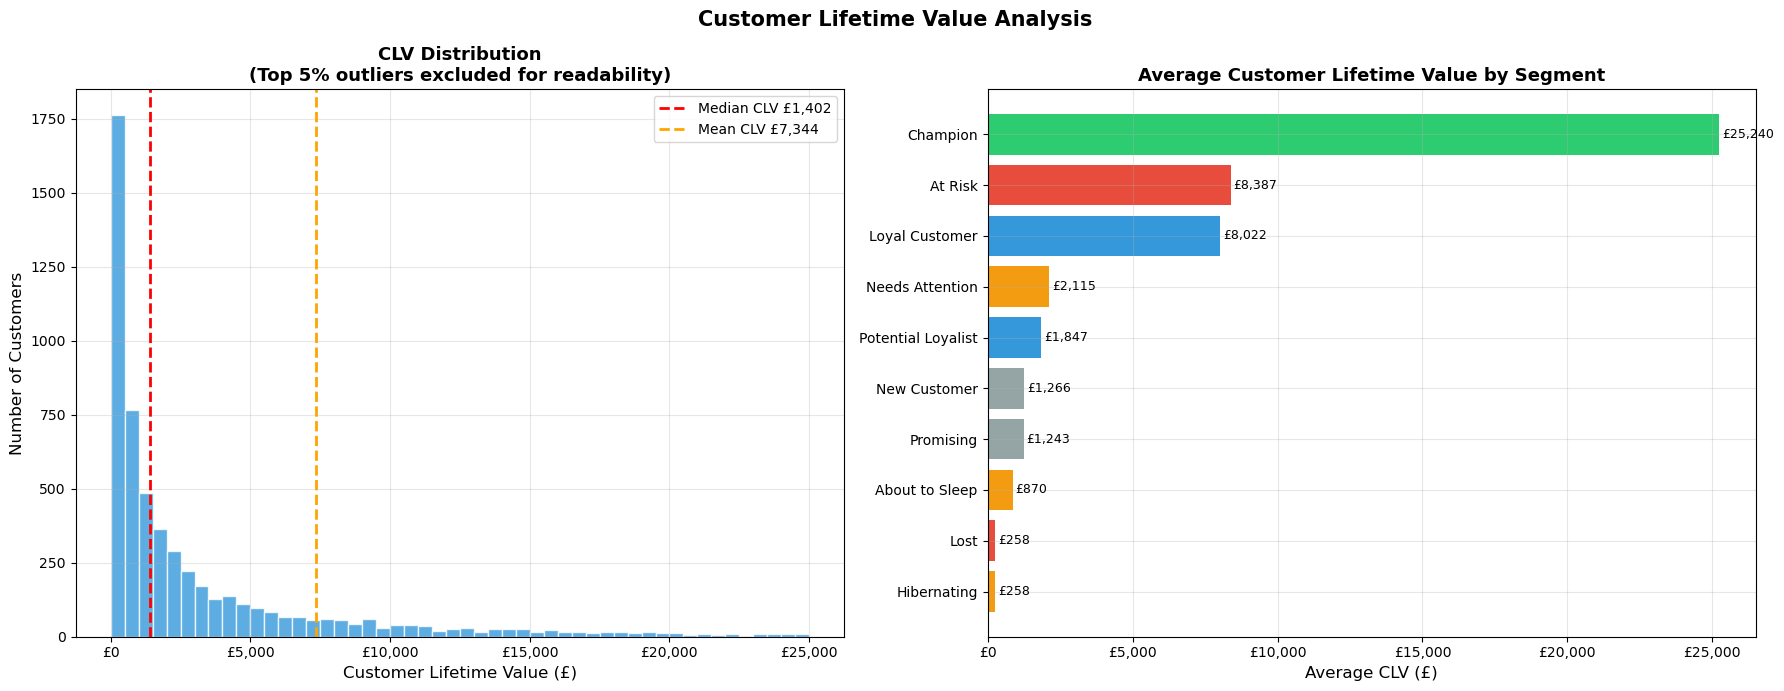

CLV chart saved to reports/figures/


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

clv_filtered = customer_clv[customer_clv['CLV'] <= customer_clv['CLV'].quantile(0.95)]
axes[0].hist(clv_filtered['CLV'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=customer_clv['CLV'].median(), color='red',
                linestyle='--', linewidth=2, label=f'Median CLV £{customer_clv["CLV"].median():,.0f}')
axes[0].axvline(x=customer_clv['CLV'].mean(), color='orange',
                linestyle='--', linewidth=2, label=f'Mean CLV £{customer_clv["CLV"].mean():,.0f}')
axes[0].set_xlabel('Customer Lifetime Value (£)', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_title('CLV Distribution\n(Top 5% outliers excluded for readability)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[0].grid(True, alpha=0.3)

seg_order = clv_by_segment.index.tolist()
colors = ['#2ecc71' if s == 'Champion' else
          '#3498db' if s in ['Loyal Customer', 'Potential Loyalist'] else
          '#e74c3c' if s in ['At Risk', 'Lost'] else
          '#f39c12' if s in ['About to Sleep', 'Hibernating', 'Needs Attention'] else
          '#95a5a6' for s in seg_order]

bars = axes[1].barh(seg_order, clv_by_segment['Avg_CLV'].values, color=colors)
axes[1].set_xlabel('Average CLV (£)', fontsize=12)
axes[1].set_title('Average Customer Lifetime Value by Segment', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(clv_by_segment['Avg_CLV'].values):
    axes[1].text(v + 100, i, f'£{v:,.0f}', va='center', fontsize=9)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\clv_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("CLV chart saved to reports/figures/")

In [6]:
print("=" * 60)
print("CUSTOMER LIFETIME VALUE SUMMARY")
print("=" * 60)
print(f"\nTotal customers analysed: {len(customer_clv):,}")
print(f"Total historical CLV: £{customer_clv['CLV'].sum():,.2f}")
print(f"\n--- CLV STATISTICS ---")
print(f"Mean CLV:   £{customer_clv['CLV'].mean():,.2f}")
print(f"Median CLV: £{customer_clv['CLV'].median():,.2f}")
print(f"Max CLV:    £{customer_clv['CLV'].max():,.2f}")
print(f"Min CLV:    £{customer_clv['CLV'].min():,.2f}")
print(f"\n--- SEGMENT CLV HIGHLIGHTS ---")
print(f"Champion avg CLV:      £{clv_by_segment.loc['Champion','Avg_CLV']:,.2f}")
print(f"At Risk avg CLV:       £{clv_by_segment.loc['At Risk','Avg_CLV']:,.2f}")
print(f"Loyal Customer avg:    £{clv_by_segment.loc['Loyal Customer','Avg_CLV']:,.2f}")
print(f"Lost avg CLV:          £{clv_by_segment.loc['Lost','Avg_CLV']:,.2f}")
print(f"Hibernating avg CLV:   £{clv_by_segment.loc['Hibernating','Avg_CLV']:,.2f}")
print(f"\n--- CONCENTRATION ---")
print(f"Top 20 customers = 25.17% of total CLV")
print(f"Top 20 all Champions except 1 bulk buyer (Customer 16446)")
print(f"\n--- KEY BUSINESS INSIGHT ---")
print(f"Champion CLV is {round(clv_by_segment.loc['Champion','Avg_CLV']/clv_by_segment.loc['Lost','Avg_CLV'],1)}x higher than Lost segment")
print(f"Champion CLV is {round(clv_by_segment.loc['Champion','Avg_CLV']/clv_by_segment.loc['At Risk','Avg_CLV'],1)}x higher than At Risk segment")
print(f"Recovering At Risk customers (223) could preserve £{clv_by_segment.loc['At Risk','Total_CLV']:,.2f} in lifetime value")
print("=" * 60)

CUSTOMER LIFETIME VALUE SUMMARY

Total customers analysed: 5,878
Total historical CLV: £43,170,677.72

--- CLV STATISTICS ---
Mean CLV:   £7,344.45
Median CLV: £1,401.88
Max CLV:    £1,755,685.98
Min CLV:    £2.95

--- SEGMENT CLV HIGHLIGHTS ---
Champion avg CLV:      £25,240.47
At Risk avg CLV:       £8,386.79
Loyal Customer avg:    £8,021.55
Lost avg CLV:          £258.12
Hibernating avg CLV:   £257.68

--- CONCENTRATION ---
Top 20 customers = 25.17% of total CLV
Top 20 all Champions except 1 bulk buyer (Customer 16446)

--- KEY BUSINESS INSIGHT ---
Champion CLV is 97.8x higher than Lost segment
Champion CLV is 3.0x higher than At Risk segment
Recovering At Risk customers (223) could preserve £1,870,253.58 in lifetime value
